In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')

# The axis labels below use the book's molar underbar, \underline{V}. With no LaTeX
# installed, matplotlib renders math with its own mathtext engine, which only learned
# \underline in 3.11 -- and Colab still ships 3.10. This upgrades it there, and does
# nothing at all on a machine that already has 3.11 or newer.
#
# ON COLAB THIS NEEDS A SESSION RESTART. Colab imports matplotlib as the session
# starts, so pip can replace the files on disk but not the module already loaded in
# memory: without a restart the kernel keeps running 3.10 and the labels still fail.
# One click, once per session. The cell prints the instruction when it applies.
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("\n" + "=" * 72)
        print("  matplotlib was upgraded so this notebook can draw the book's notation.")
        print("  RESTART NOW:   Runtime > Restart session,   then Run all.")
        print("  Colab only, once per session. Without it the next figure will fail.")
        print("=" * 72 + "\n")
# ---------------------------------------------------------------------------


# Figure 9.5-1 &mdash; the excess Gibbs energy against composition

This notebook reproduces **Figure 9.5-1**: $\underline{G}^{\rm ex}$ for the benzene /
2,2,4-trimethyl pentane mixture.

Figure 9.5-2 puts four other mixtures beside it. The point of the pair is that every
curve has the same simple shape &mdash; it vanishes at both pure limits and has one
extremum &mdash; which is *why* fitting a polynomial in composition is a sensible thing
to do at all.

**Figure 9.5-2 is not recomputed here, and should not be.** Its four curves are
other people's measurements &mdash; Mathot and Desmyter (1953), Cutler and Morrison
(1965), and two more &mdash; and we hold neither the data nor the right to redraw them.
It keeps its existing art. This notebook draws Fig. 9.5-1 from the book's own data, and then
makes the second point **with the models rather than with five literature datasets**:
the same $\underline{G}^{\rm ex}$ curve, and the very different activity coefficients
that models agreeing on it can still produce.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from thermo.charts import use_book_style
use_book_style()
R = constants.R

In [3]:
# Weissman and Wood, benzene(B)/2,2,4-trimethyl pentane(TMP) at 55 C (SIS Illus. 10.2-4)
T = 328.15
xB    = np.array([0.0819, 0.2192, 0.3584, 0.3831, 0.5256, 0.8478, 0.9872])
yB    = np.array([0.1869, 0.4065, 0.5509, 0.5748, 0.6786, 0.8741, 0.9863])
P_bar = np.array([0.26892, 0.31573, 0.35463, 0.36088, 0.39105, 0.43277, 0.43641])
Pvap_B, Pvap_TMP = 0.43596, 0.23738
gB = yB * P_bar / (xB * Pvap_B)
gT = (1 - yB) * P_bar / ((1 - xB) * Pvap_TMP)
gex = R * T * (xB * np.log(gB) + (1 - xB) * np.log(gT))
print("Gex (J/mol):", np.round(gex, 2))

Gex (J/mol): [ 84.67 199.7  296.72 305.19 352.61 224.28  23.96]


## Figure 9.5-1

Weissman and Wood's own three-term Redlich–Kister fit, $a$ = (1389.0, 419.45, 109.83)
J/mol, is the smooth curve. It reproduces every smoothed value printed in Illustration
10.2-4.

maximum 355 J/mol at x_B = 0.58


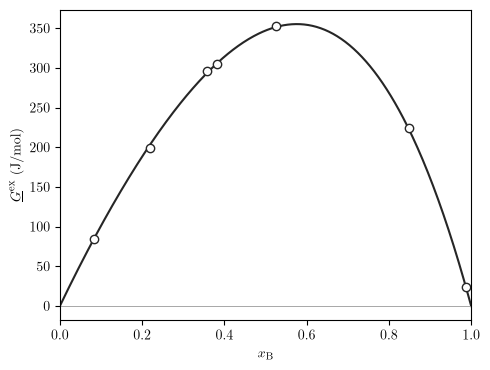

In [4]:
from thermo import RedlichKisterGex
rk = RedlichKisterGex([1389.0, 419.45, 109.83])
x = np.linspace(0, 1, 400)
curve = np.array([0 if a in (0.0, 1.0) else rk.gex([a, 1-a], T) for a in x])

fig, ax = plt.subplots(figsize=(5.0, 3.8))
ax.plot(x, curve, "-", color="0.15")
ax.plot(xB, gex, "o", mfc="white", color="0.15")
ax.axhline(0, lw=0.6, color="0.6")
ax.set_xlabel(r"$x_{\mathrm{B}}$"); ax.set_ylabel(r"$\underline{G}^{\rm ex}$  (J/mol)")
ax.set_xlim(0, 1)
fig.tight_layout()
print(f"maximum {curve.max():.0f} J/mol at x_B = {x[curve.argmax()]:.2f}")

In [5]:
# --- Print art: Figure 9.5-1 -----------------------------------------------
# Stage as deliverables/figures/print-bw/ch9/c09f002.pdf
#
# Typography comes from use_book_style() at the top: serif Computer Modern, and
# pdf.fonttype 42 so production can re-set a label without regenerating the art.
# A figure that comes out in DejaVu Sans has not called it.
import os
os.makedirs("pdf", exist_ok=True)
fig.savefig("pdf/Fig_9.5-1.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Fig_9.5-1.pdf")

wrote pdf/Fig_9.5-1.pdf


## The shape is generic; the activity coefficients are not

Here is the useful thing a notebook can do that a printed figure cannot. Fit **four
different models** so that they agree on $\underline{G}^{\rm ex}$ as closely as each can,
then look at what they say about the individual activity coefficients.

In [6]:
from thermo import (OneConstantMargules, TwoConstantMargules, VanLaar, Wilson)

models = {
    "one-constant Margules": OneConstantMargules.fit(xB, gB, gT, T),
    "two-constant Margules": TwoConstantMargules.fit(xB, gB, gT, T),
    "van Laar":              VanLaar.fit(xB, gB, gT),
    "Wilson":                Wilson.fit(xB, gB, gT),
    "Redlich-Kister (3)":    rk,
}
for name, m in models.items():
    print(f"  {name:24s} Gibbs-Duhem residual {m.check_gibbs_duhem(T):.1e}")

  one-constant Margules    Gibbs-Duhem residual 4.2e-17
  two-constant Margules    Gibbs-Duhem residual 5.6e-17
  van Laar                 Gibbs-Duhem residual 5.6e-17
  Wilson                   Gibbs-Duhem residual 2.7e-16
  Redlich-Kister (3)       Gibbs-Duhem residual 5.6e-17


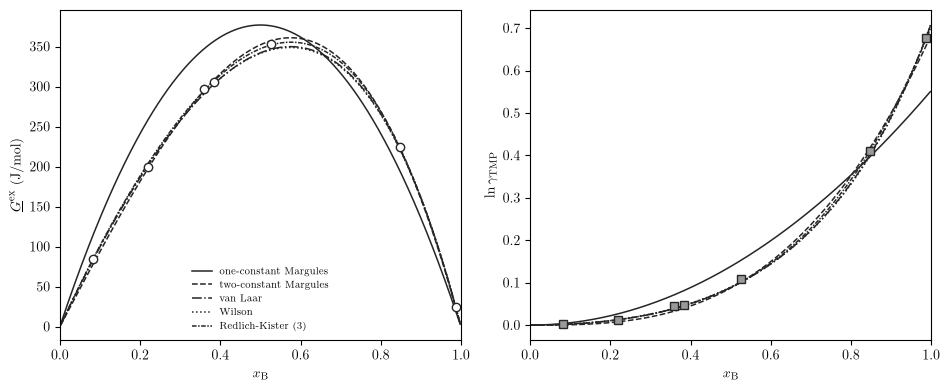

In [7]:
xs = np.linspace(0.002, 0.998, 400)
fig, ax = plt.subplots(1, 2, figsize=(9.6, 4))
styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]   # dash tuples need ls=, not a format string
for (name, m), st in zip(models.items(), styles):
    ge = np.array([m.gex([a, 1-a], T) for a in xs])
    lg = np.array([m.lngamma([a, 1-a], T) for a in xs])
    ax[0].plot(xs, ge, ls=st, color="0.15", lw=1.1, label=name)
    ax[1].plot(xs, lg[:, 1], ls=st, color="0.15", lw=1.1, label=name)
ax[0].plot(xB, gex, "o", mfc="white", color="0.15")
ax[1].plot(xB, np.log(gT), "s", mfc="0.6", color="0.15")
ax[0].set_ylabel(r"$\underline{G}^{\rm ex}$  (J/mol)")
ax[1].set_ylabel(r"$\ln\gamma_{\mathrm{TMP}}$")
for a in ax:
    a.set_xlabel(r"$x_{\mathrm{B}}$"); a.set_xlim(0, 1)
ax[0].legend(frameon=False, fontsize=7)
fig.tight_layout()

In [8]:
print("infinite-dilution activity coefficients, where the models part company:")
print(f"{'model':26s}{'gamma_B^inf':>13}{'gamma_TMP^inf':>15}")
for name, m in models.items():
    g0 = m.gamma([1e-9, 1-1e-9], T)[0]
    g1 = m.gamma([1-1e-9, 1e-9], T)[1]
    print(f"{name:26s}{g0:13.3f}{g1:15.3f}")
print(f"\nmeasured, at the most dilute points available: "
      f"gamma_B = {gB[0]:.3f} at x_B = {xB[0]}, gamma_TMP = {gT[-1]:.3f} at x_B = {xB[-1]}")

infinite-dilution activity coefficients, where the models part company:
model                       gamma_B^inf  gamma_TMP^inf
one-constant Margules             1.738          1.738
two-constant Margules             1.418          1.981
van Laar                          1.474          2.034
Wilson                            1.478          2.039
Redlich-Kister (3)                1.485          2.020

measured, at the most dilute points available: gamma_B = 1.408 at x_B = 0.0819, gamma_TMP = 1.968 at x_B = 0.9872


**They agree in the middle and disagree at the ends** — and the ends are where a
bubble-point or a liquid–liquid calculation actually lives. The one-constant Margules
equation is forced to give the same $\gamma^\infty$ for both species, which the data
plainly deny. The others spread by tens of percent in a region where there are no data
at all.

That is the honest reason Sec. 9.11's *"choosing the model"* tables exist, and the
reason this module puts every model behind one interface: the choice cannot be made by
looking at how well a curve passes through the middle of the data.

**Your turn.** Add `NRTL` (`NRTL.fit(xB, gB, gT, alpha=0.3)`) to the dictionary and
re-run. Then change $\alpha$ to 0.2 and to 0.47, the ends of the range Renon and
Prausnitz recommend, and see how much the infinite-dilution predictions move for a
parameter you are told not to fit.